# 02. Transparent Models as First-Class Baselines

A common failure mode in applied machine learning is to treat transparent models as disposable warm-up exercises. Teams fit a linear or logistic model, note that a more flexible method improves a metric slightly, and then move on as if the baseline no longer matters. In decision science, that is often backwards. A transparent baseline is a number to beat and a candidate deployment model. It is a candidate deployment model, a debugging instrument, a governance anchor, and a disciplined test of whether added complexity earns its keep.

This notebook develops that idea mathematically and operationally. We will build transparent baselines for both a continuous workload target and a binary review-allocation target, compare them with boosting models, examine sparsity as a design choice rather than only a statistical penalty, and construct a scorecard-style version of the review model that could plausibly be used in a high-accountability workflow.

The objective is not to argue that transparent models always dominate. The objective is to show that in many tabular decision problems they are already strong, interpretable, and often close enough to the best available model that they deserve to be taken seriously.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why transparent models are legitimate deployment candidates rather than only preliminary baselines.
2. Write down linear and logistic transparent models as risk or workload scoring systems tied to a decision problem.
3. Fit and interpret ridge and logistic baselines for continuous and binary operational targets.
4. Use sparsity to trade a small amount of flexibility for a large gain in parsimony.
5. Build a scorecard-style binned logistic model and translate coefficients into integer-style points.
6. Compare transparent and flexible models using both predictive metrics and deployment utility.
7. State a principled deployment rule for when a transparent model is already good enough.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 140)
np.random.seed(2026)

CATEGORICAL_LEVELS = {
    'segment': ['growth', 'mid-market', 'enterprise'],
    'region': ['North', 'South', 'West', 'International'],
    'support_motion': ['pooled', 'named-csm', 'white-glove'],
}

SCORECARD_LEVELS = {
    'tickets_bin': ['0-1', '2-3', '4+'],
    'complexity_bin': ['1-4', '5-6', '7+'],
    'training_bin': ['<0.55', '0.55-0.75', '0.75+'],
    'adoption_bin': ['<0.45', '0.45-0.70', '0.70+'],
    'delay_bin': ['0-2', '3-7', '8+'],
    'incident_bin': ['0', '1', '2+'],
    'volatility_bin': ['<0.6', '0.6-1.2', '1.2+'],
    'segment': CATEGORICAL_LEVELS['segment'],
    'region': CATEGORICAL_LEVELS['region'],
}


def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))


def make_one_hot_encoder(categories=None, drop='first'):
    """Construct the one hot encoder helper used in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    categories : object
        The categories setting that controls the one hot encoder calculation in this notebook.
    drop : object
        The drop setting that controls the one hot encoder calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    encoder_kwargs = {
        'handle_unknown': 'ignore',
        'drop': drop,
    }
    if categories is not None:
        encoder_kwargs['categories'] = categories
    try:
        return OneHotEncoder(sparse_output=False, **encoder_kwargs)
    except TypeError:
        return OneHotEncoder(sparse=False, **encoder_kwargs)


def clean_feature_name(name):
    """Clean feature name so it can be interpreted in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    name : object
        Readable name used to label a model, variable, scenario, or diagnostic object.
    
    Returns
    -------
    object
        Intermediate result produced by the feature name calculation and reused by later cells.
    """
    cleaned = name.replace('num__', '').replace('cat__', '')
    replacements = {
        'segment_': 'segment = ',
        'region_': 'region = ',
        'support_motion_': 'support_motion = ',
        'tickets_bin_': 'tickets bin = ',
        'complexity_bin_': 'complexity bin = ',
        'training_bin_': 'training bin = ',
        'adoption_bin_': 'adoption bin = ',
        'delay_bin_': 'delay bin = ',
        'incident_bin_': 'incident bin = ',
        'volatility_bin_': 'volatility bin = ',
    }
    for old, new in replacements.items():
        cleaned = cleaned.replace(old, new)
    return cleaned


def coefficient_table_from_pipeline(pipeline):
    """Carry out the coefficient table from pipeline step used in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    pipeline : object
        Scikit-learn pipeline that combines preprocessing and estimation.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the coefficient table from pipeline workflow for later analysis.
    """
    prep = pipeline.named_steps['prep']
    model = pipeline.named_steps['model']
    feature_names = [clean_feature_name(name) for name in prep.get_feature_names_out()]
    coef = np.asarray(model.coef_).ravel()
    table = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
    table['abs_coefficient'] = table['coefficient'].abs()
    return table.sort_values('abs_coefficient', ascending=False)


def support_metrics(y_true, y_pred):
    """Carry out the support metrics step used in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        'rmse': rmse,
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }


def review_metrics(y_true, prob):
    """Carry out the review metrics step used in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    prob : object
        Rate or probability parameter controlling this calculation.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    return {
        'roc_auc': roc_auc_score(y_true, prob),
        'average_precision': average_precision_score(y_true, prob),
        'brier_score': brier_score_loss(y_true, prob),
        'log_loss': log_loss(y_true, prob),
    }


def policy_summary(probabilities, outcomes, thresholds):
    """Carry out the policy summary step used in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    probabilities : object
        Predicted probabilities used by the decision rule.
    outcomes : object
        The outcomes setting that controls the policy summary calculation in this notebook.
    thresholds : object
        Candidate decision cutoffs compared by the evaluation step.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    outcomes = np.asarray(outcomes)
    rows = []
    for threshold in thresholds:
        action = (probabilities >= threshold).astype(int)
        utility = np.select(
            [
                (action == 1) & (outcomes == 1),
                (action == 1) & (outcomes == 0),
                (action == 0) & (outcomes == 1),
            ],
            [900, -110, -1450],
            default=0,
        )
        tp = ((action == 1) & (outcomes == 1)).sum()
        fp = ((action == 1) & (outcomes == 0)).sum()
        fn = ((action == 0) & (outcomes == 1)).sum()
        rows.append(
            {
                'threshold': threshold,
                'mean_utility': utility.mean(),
                'review_share': action.mean(),
                'precision': tp / max(tp + fp, 1),
                'recall': tp / max(tp + fn, 1),
            }
        )
    return pd.DataFrame(rows)


def make_scorecard_frame(df):
    """Construct the scorecard frame helper used in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    frame = pd.DataFrame(index=df.index)
    frame['tickets_bin'] = pd.Categorical(
        pd.cut(df['open_tickets_30d'], bins=[-0.1, 1.5, 3.5, np.inf], labels=SCORECARD_LEVELS['tickets_bin']),
        categories=SCORECARD_LEVELS['tickets_bin'],
        ordered=True,
    )
    frame['complexity_bin'] = pd.Categorical(
        pd.cut(df['integration_complexity'], bins=[0.0, 4.5, 6.5, np.inf], labels=SCORECARD_LEVELS['complexity_bin']),
        categories=SCORECARD_LEVELS['complexity_bin'],
        ordered=True,
    )
    frame['training_bin'] = pd.Categorical(
        pd.cut(df['training_completion'], bins=[-0.01, 0.55, 0.75, 1.01], labels=SCORECARD_LEVELS['training_bin']),
        categories=SCORECARD_LEVELS['training_bin'],
        ordered=True,
    )
    frame['adoption_bin'] = pd.Categorical(
        pd.cut(df['product_adoption'], bins=[-0.01, 0.45, 0.70, 1.01], labels=SCORECARD_LEVELS['adoption_bin']),
        categories=SCORECARD_LEVELS['adoption_bin'],
        ordered=True,
    )
    frame['delay_bin'] = pd.Categorical(
        pd.cut(df['payment_delay_days'], bins=[-0.1, 2.5, 7.5, np.inf], labels=SCORECARD_LEVELS['delay_bin']),
        categories=SCORECARD_LEVELS['delay_bin'],
        ordered=True,
    )
    frame['incident_bin'] = pd.Categorical(
        pd.cut(df['recent_incidents_90d'], bins=[-0.1, 0.5, 1.5, np.inf], labels=SCORECARD_LEVELS['incident_bin']),
        categories=SCORECARD_LEVELS['incident_bin'],
        ordered=True,
    )
    frame['volatility_bin'] = pd.Categorical(
        pd.cut(df['usage_volatility'], bins=[-0.01, 0.6, 1.2, np.inf], labels=SCORECARD_LEVELS['volatility_bin']),
        categories=SCORECARD_LEVELS['volatility_bin'],
        ordered=True,
    )
    frame['segment'] = pd.Categorical(df['segment'], categories=SCORECARD_LEVELS['segment'])
    frame['region'] = pd.Categorical(df['region'], categories=SCORECARD_LEVELS['region'])
    return frame


def scorecard_points_table(scorecard_pipeline, point_scale=0.20):
    """Carry out the scorecard points table step used in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    scorecard_pipeline : object
        Model object, learner, or pipeline being fitted, scored, or explained.
    point_scale : object
        The point scale setting that controls the scorecard points table calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    prep = scorecard_pipeline.named_steps['prep']
    model = scorecard_pipeline.named_steps['model']
    feature_names = list(prep.get_feature_names_out())
    coefficients = np.asarray(model.coef_).ravel()
    raw_map = {clean_feature_name(name): coef for name, coef in zip(feature_names, coefficients)}

    rows = []
    pretty_prefix = {
        'tickets_bin': 'tickets bin = ',
        'complexity_bin': 'complexity bin = ',
        'training_bin': 'training bin = ',
        'adoption_bin': 'adoption bin = ',
        'delay_bin': 'delay bin = ',
        'incident_bin': 'incident bin = ',
        'volatility_bin': 'volatility bin = ',
        'segment': 'segment = ',
        'region': 'region = ',
    }
    for feature, levels in SCORECARD_LEVELS.items():
        for level_index, level in enumerate(levels):
            label = pretty_prefix[feature] + str(level)
            coef = raw_map.get(label, 0.0)
            points = int(np.round(coef / point_scale)) if level_index > 0 else 0
            rows.append({'feature_group': feature, 'level': str(level), 'coefficient': coef, 'points': points})
    return pd.DataFrame(rows)


## 1. Why Transparent Baselines Deserve Serious Attention

A transparent model class is one in which the path from input to prediction can be inspected directly, either through coefficients, explicit bins, or short rules. That does **not** mean the model is always simple in a trivial sense. It means the scoring logic itself is inspectable without a second explanatory model layered on top.

A useful decision-science framing is:

$$
\hat f_{\text{deploy}} = \arg\max_{f \in \mathcal{F}} \hat V(f) \quad \text{subject to} \quad f \in \mathcal{G},
$$

where $\hat V(f)$ is the estimated deployment value of model $f$ and $\mathcal{G}$ is the set of models that satisfy governance and communication requirements. Transparent models matter because they often belong to $\mathcal{G}$ by construction.

In practice they serve four roles at once:

| Role | Why it matters |
|---|---|
| Deployment candidate | The baseline may already be strong enough to use directly |
| Benchmark | It tells us whether a more complex model is earning its complexity |
| Debugging instrument | Transparent coefficients and rules expose leakage, unstable signals, or strange category effects quickly |
| Governance anchor | It gives stakeholders a model whose logic can be audited without extra machinery |

This notebook treats transparent baselines as first-class models by evaluating them against two operational targets and by asking whether they predict well and whether they can be turned into usable decision tools.

## 2. Synthetic Case Study: Account Triage and Support Burden

We will simulate a platform-operations dataset in which one account is observed over the current month and the organization wants to answer two distinct questions about the next month:

1. **How many specialist support hours will this account likely require?**
2. **Should this account be escalated into specialist review now?**

This gives us a continuous target and a binary decision target inside one coherent business workflow.

The data-generating process is mostly additive, with a few mild threshold effects. That is deliberate. Many tabular operational problems do have nonlinearities, but those nonlinearities are often not so extreme that a transparent model becomes useless.

| Variable | Operational role | Interpretation note |
|---|---|---|
| `open_tickets_30d` | Recent workload pressure | More unresolved issues usually imply greater future support burden |
| `integration_complexity` | Technical difficulty | Harder implementations often require more specialist time |
| `training_completion` | Customer enablement | Better-trained customers tend to generate fewer preventable escalations |
| `product_adoption` | Product maturity | Healthy adoption can stabilize an account, though not always linearly |
| `payment_delay_days` | Commercial friction marker | Often predictive, but predictive, with causal status requiring separate evidence |
| `recent_incidents_90d` | Reliability stress signal | Recent incidents often forecast future operational load |
| `usage_volatility` | Instability signal | Fast swings in usage can make support planning harder |
| `executive_sponsor` | Internal coordination strength | Strong sponsorship can reduce avoidable escalation |
| `segment`, `region`, `support_motion` | Structural context | These capture business heterogeneity and workflow differences |
| `support_hours_next_30d` | Continuous target | Used for planning specialist staffing burden |
| `needs_specialist_review` | Binary target | Used for proactive triage decisions |


In [2]:
# Section focus: 2. Synthetic Case Study: Account Triage and Support Burden.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_triage_dataset(n=7000, seed=2026):
    """Construct the triage dataset helper used in the 02. Transparent Models as First-Class Baselines workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(CATEGORICAL_LEVELS['segment'], size=n, p=[0.50, 0.31, 0.19])
    region = rng.choice(CATEGORICAL_LEVELS['region'], size=n, p=[0.30, 0.24, 0.28, 0.18])
    support_motion = rng.choice(CATEGORICAL_LEVELS['support_motion'], size=n, p=[0.52, 0.33, 0.15])

    executive_sponsor = rng.binomial(1, p=np.where(segment == 'enterprise', 0.72, np.where(segment == 'mid-market', 0.44, 0.21)), size=n)
    open_tickets_30d = rng.poisson(1.6 + 0.9 * (segment == 'mid-market') + 1.8 * (segment == 'enterprise'))
    integration_complexity = np.clip(
        rng.normal(4.5 + 0.8 * (segment == 'mid-market') + 1.5 * (segment == 'enterprise'), 1.3, n),
        1.0,
        10.0,
    )
    training_completion = np.clip(
        0.70 + 0.12 * rng.normal(size=n) - 0.07 * (support_motion == 'pooled') - 0.04 * (region == 'International'),
        0.03,
        0.99,
    )
    product_adoption = np.clip(
        0.60 + 0.12 * rng.normal(size=n) - 0.06 * integration_complexity / 10 + 0.10 * executive_sponsor,
        0.03,
        0.99,
    )
    payment_delay_days = np.clip(
        rng.gamma(shape=1.8 + 0.25 * (segment == 'growth'), scale=2.3, size=n) + 0.8 * (region == 'International'),
        0.0,
        30.0,
    )
    recent_incidents_90d = rng.poisson(0.6 + 0.22 * (region == 'West') + 0.20 * (segment == 'enterprise'))
    usage_volatility = np.clip(rng.gamma(shape=2.0, scale=0.43, size=n), 0.02, 4.0)
    latent_load = rng.normal(0.0, 1.0, n) + 0.22 * (segment == 'enterprise') + 0.16 * (support_motion == 'pooled')

    support_hours_next_30d = (
        2.5
        + 0.95 * open_tickets_30d
        + 0.48 * integration_complexity
        + 1.75 * usage_volatility
        + 1.40 * recent_incidents_90d
        + 0.09 * payment_delay_days
        - 3.90 * training_completion
        - 2.20 * product_adoption
        - 1.25 * executive_sponsor
        + 1.10 * (support_motion == 'pooled')
        + 0.65 * (region == 'International')
        + 1.10 * np.maximum(usage_volatility - 1.2, 0.0)
        + 0.85 * ((open_tickets_30d >= 5) & (training_completion < 0.60))
        + 1.25 * latent_load
        + rng.normal(0.0, 1.6, n)
    )
    support_hours_next_30d = np.clip(support_hours_next_30d, 0.5, None)

    eta = (
        -4.05
        + 0.18 * open_tickets_30d
        + 0.15 * integration_complexity
        + 0.62 * usage_volatility
        + 0.34 * recent_incidents_90d
        + 0.06 * payment_delay_days
        - 1.55 * training_completion
        - 0.95 * product_adoption
        - 0.42 * executive_sponsor
        + 0.18 * (segment == 'enterprise')
        + 0.14 * (region == 'International')
        + 0.32 * np.maximum(usage_volatility - 1.1, 0.0)
        + 0.38 * ((open_tickets_30d >= 5) & (training_completion < 0.60))
        + 0.62 * latent_load
    )
    needs_specialist_review = rng.binomial(1, sigmoid(eta))

    return pd.DataFrame(
        {
            'segment': segment,
            'region': region,
            'support_motion': support_motion,
            'executive_sponsor': executive_sponsor,
            'open_tickets_30d': open_tickets_30d,
            'integration_complexity': integration_complexity,
            'training_completion': training_completion,
            'product_adoption': product_adoption,
            'payment_delay_days': payment_delay_days,
            'recent_incidents_90d': recent_incidents_90d,
            'usage_volatility': usage_volatility,
            'support_hours_next_30d': support_hours_next_30d,
            'needs_specialist_review': needs_specialist_review,
        }
    )


df = make_triage_dataset()

overview = pd.DataFrame(
    {
        'quantity': [
            'Accounts',
            'Mean support hours next 30d',
            'Review rate',
            'Mean open tickets 30d',
            'Mean training completion',
        ],
        'value': [
            len(df),
            df['support_hours_next_30d'].mean(),
            df['needs_specialist_review'].mean(),
            df['open_tickets_30d'].mean(),
            df['training_completion'].mean(),
        ],
    }
)

segment_summary = (
    df.groupby('segment', observed=False)
    .agg(
        accounts=('needs_specialist_review', 'size'),
        mean_support_hours=('support_hours_next_30d', 'mean'),
        review_rate=('needs_specialist_review', 'mean'),
        mean_open_tickets=('open_tickets_30d', 'mean'),
    )
    .reset_index()
)

smart_display(overview)
smart_display(segment_summary)


,quantity,value
0,Accounts,7000.000
1,Mean support hours next 30d,6.605
2,Review rate,0.049
3,Mean open tickets 30d,2.211
4,Mean training completion,0.656


,segment,accounts,mean_support_hours,review_rate,mean_open_tickets
0,enterprise,1362,8.085,0.074,3.294
1,growth,3435,5.955,0.038,1.568
2,mid-market,2203,6.705,0.049,2.543


Use Synthetic Case Study: Account Triage and Support Burden to test whether the explanation story is credible. The displayed reasons should line up with the data-generating story and the operating decision, and unstable attributions should be called out clearly.


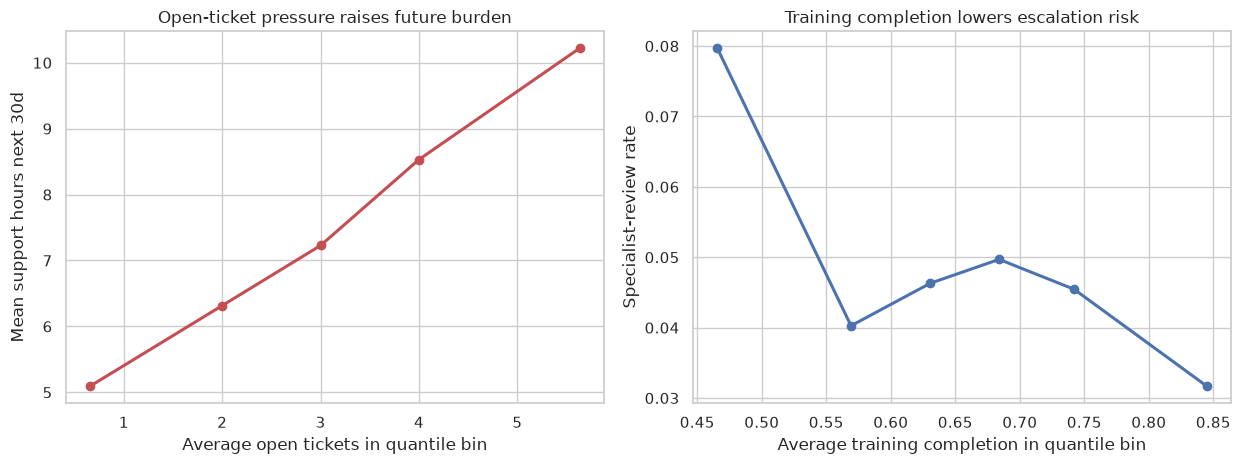

In [3]:
ticket_summary = (
    df.groupby(pd.qcut(df['open_tickets_30d'], q=6, duplicates='drop'), observed=False)
    .agg(mean_tickets=('open_tickets_30d', 'mean'), mean_support_hours=('support_hours_next_30d', 'mean'), review_rate=('needs_specialist_review', 'mean'))
    .reset_index(drop=True)
)
training_summary = (
    df.groupby(pd.qcut(df['training_completion'], q=6, duplicates='drop'), observed=False)
    .agg(mean_training=('training_completion', 'mean'), mean_support_hours=('support_hours_next_30d', 'mean'), review_rate=('needs_specialist_review', 'mean'))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))
axes[0].plot(ticket_summary['mean_tickets'], ticket_summary['mean_support_hours'], marker='o', linewidth=2.2, color='#c44e52', label='Support hours')
axes[0].set_title('Open-ticket pressure raises future burden')
axes[0].set_xlabel('Average open tickets in quantile bin')
axes[0].set_ylabel('Mean support hours next 30d')

axes[1].plot(training_summary['mean_training'], training_summary['review_rate'], marker='o', linewidth=2.2, color='#4c72b0', label='Review rate')
axes[1].set_title('Training completion lowers escalation risk')
axes[1].set_xlabel('Average training completion in quantile bin')
axes[1].set_ylabel('Specialist-review rate')

plt.tight_layout()
plt.show()


The basic plots already hint that transparent models should do reasonably well here.

- The signal is largely monotone: more ticket pressure tends to increase workload, while stronger enablement tends to reduce escalation risk.
- There are some threshold effects, especially in high-volatility or high-ticket accounts, but the dominant structure is still additive enough to favor transparent baselines.
- This is precisely the kind of setting where teams should resist the impulse to skip straight to highly flexible models.

## 3. Transparent Regression Baseline for Staffing Burden

For the continuous target, we use a ridge model. If the numeric design matrix is standardized and categorical variables are baseline-coded, the fitted model has the form

$$
\hat y_i = \beta_0 + x_i^\top \beta,
$$

with ridge estimate

$$
\hat\beta_{\text{ridge}} = \arg\min_\beta \sum_{i=1}^n (y_i - \beta_0 - x_i^\top \beta)^2 + \lambda \|\beta\|_2^2.
$$

The purpose of the penalty here is not opacity. It is stabilization. Operational features are often correlated, and a small amount of shrinkage reduces coefficient volatility while preserving a model that remains fully inspectable.

,model,rmse,mae,r2
0,Ridge baseline,1.990,1.581,0.655
1,Boosted regressor,2.038,1.624,0.639


,feature,coefficient
1,open_tickets_30d,1.587
7,usage_volatility,1.286
13,support_motion = named-csm,-1.282
14,support_motion = white-glove,-1.264
6,recent_incidents_90d,1.155
12,region = International,0.676
2,integration_complexity,0.603
0,executive_sponsor,-0.587
3,training_completion,-0.508
4,product_adoption,-0.317


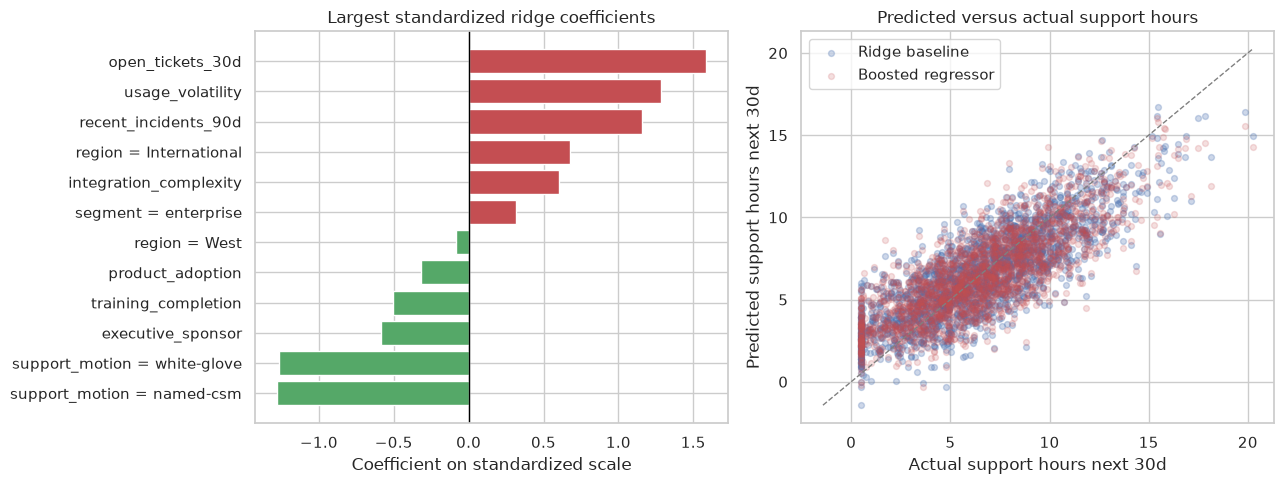

In [4]:
# Section focus: 3. Transparent Regression Baseline for Staffing Burden.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

feature_cols = [
    'segment', 'region', 'support_motion', 'executive_sponsor', 'open_tickets_30d', 'integration_complexity',
    'training_completion', 'product_adoption', 'payment_delay_days', 'recent_incidents_90d', 'usage_volatility'
]
numeric_features = ['executive_sponsor', 'open_tickets_30d', 'integration_complexity', 'training_completion', 'product_adoption', 'payment_delay_days', 'recent_incidents_90d', 'usage_volatility']
categorical_features = ['segment', 'region', 'support_motion']

X = df[feature_cols].copy()
y_reg = df['support_hours_next_30d'].copy()
y_cls = df['needs_specialist_review'].copy()

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X,
    y_reg,
    y_cls,
    test_size=0.30,
    random_state=2026,
    stratify=y_cls,
)

transparent_prep = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', make_one_hot_encoder(categories=[CATEGORICAL_LEVELS[name] for name in categorical_features], drop='first'), categorical_features),
    ]
)

ridge_model = Pipeline(
    steps=[
        ('prep', transparent_prep),
        ('model', Ridge(alpha=1.0)),
    ]
)

boost_reg_model = Pipeline(
    steps=[
        ('prep', transparent_prep),
        ('model', HistGradientBoostingRegressor(max_depth=4, learning_rate=0.06, max_iter=250, random_state=2026)),
    ]
)

ridge_model.fit(X_train, y_reg_train)
boost_reg_model.fit(X_train, y_reg_train)

ridge_pred = ridge_model.predict(X_test)
boost_reg_pred = boost_reg_model.predict(X_test)

regression_comparison = pd.DataFrame(
    [
        {'model': 'Ridge baseline', **support_metrics(y_reg_test, ridge_pred)},
        {'model': 'Boosted regressor', **support_metrics(y_reg_test, boost_reg_pred)},
    ]
)

smart_display(regression_comparison)

ridge_coef = coefficient_table_from_pipeline(ridge_model)
smart_display(ridge_coef[['feature', 'coefficient']].head(12))

plot_reg = pd.concat([ridge_coef.nsmallest(6, 'coefficient'), ridge_coef.nlargest(6, 'coefficient')]).drop_duplicates('feature').sort_values('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
colors = np.where(plot_reg['coefficient'] > 0, '#c44e52', '#55a868')
axes[0].barh(plot_reg['feature'], plot_reg['coefficient'], color=colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Largest standardized ridge coefficients')
axes[0].set_xlabel('Coefficient on standardized scale')

axes[1].scatter(y_reg_test, ridge_pred, alpha=0.28, s=18, color='#4c72b0', label='Ridge baseline')
axes[1].scatter(y_reg_test, boost_reg_pred, alpha=0.18, s=18, color='#c44e52', label='Boosted regressor')
line_min = min(y_reg_test.min(), ridge_pred.min(), boost_reg_pred.min())
line_max = max(y_reg_test.max(), ridge_pred.max(), boost_reg_pred.max())
axes[1].plot([line_min, line_max], [line_min, line_max], linestyle='--', color='gray', linewidth=1)
axes[1].set_title('Predicted versus actual support hours')
axes[1].set_xlabel('Actual support hours next 30d')
axes[1].set_ylabel('Predicted support hours next 30d')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


The ridge model gives us two valuable things immediately.

- It provides a credible workload forecast baseline.
- It also reveals which inputs are doing the main explanatory work on the standardized scale.

In this run, ridge is highly competitive; it slightly outperforms the boosted regressor on RMSE, MAE, and $R^2$. That matters because extra model flexibility did not buy better generalization here. The transparent baseline is already strong enough to serve as both a benchmark and a plausible operational model.

## 4. Transparent Logistic Baseline for Triage Decisions

For the binary target, we start with a logistic model. With standardized numeric inputs and baseline-coded categories, the score is

$$
\Pr(Y=1 \mid X=x) = \sigma(\beta_0 + x^\top \beta), \qquad \sigma(z)=\frac{1}{1+e^{-z}}.
$$

The logistic objective can be written as empirical cross-entropy minimization:

$$
\hat\beta = \arg\min_\beta \left[-\sum_{i=1}^n y_i \log p_i - \sum_{i=1}^n (1-y_i)\log(1-p_i)\right],
$$

where $p_i = \sigma(\beta_0 + x_i^\top \beta)$. This gives an interpretable probability model whose coefficients can be read as shifts in log-odds relative to the baseline categories.

,model,roc_auc,average_precision,brier_score,log_loss
0,Dense logistic baseline,0.753,0.208,0.043,0.172
1,Boosted classifier,0.722,0.174,0.044,0.180


,feature,coefficient,odds_ratio
7,usage_volatility,0.501,1.650
4,product_adoption,-0.318,0.728
9,segment = enterprise,0.308,1.361
1,open_tickets_30d,0.302,1.352
12,region = International,0.278,1.320
2,integration_complexity,0.269,1.309
6,recent_incidents_90d,0.268,1.307
3,training_completion,-0.254,0.776
11,region = West,-0.253,0.777
10,region = South,0.211,1.235


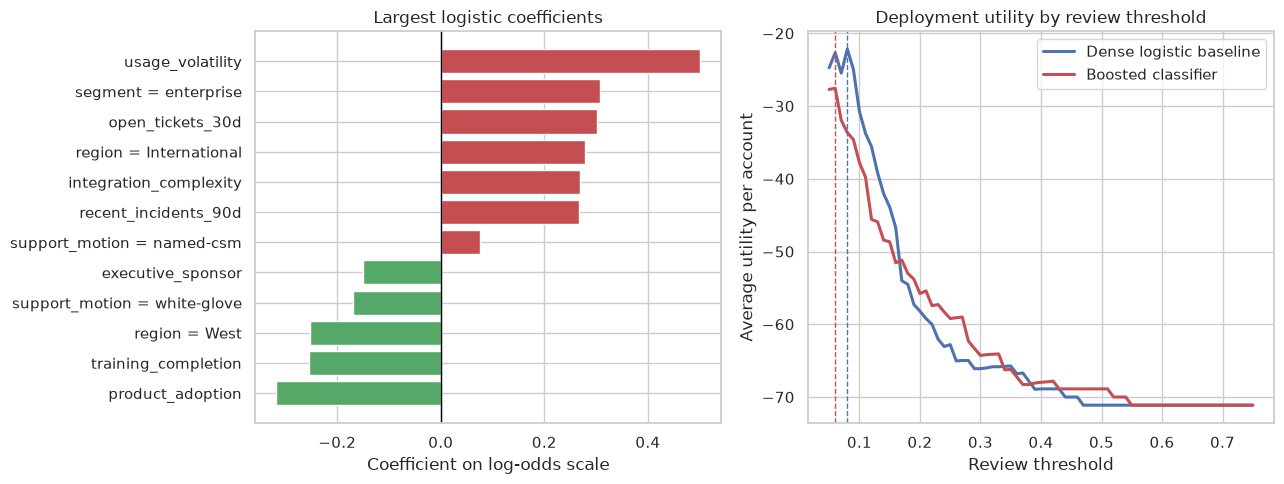

In [5]:
# Section focus: 4. Transparent Logistic Baseline for Triage Decisions.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

dense_logit_model = Pipeline(
    steps=[
        ('prep', transparent_prep),
        ('model', LogisticRegression(max_iter=4000)),
    ]
)

boost_cls_model = Pipeline(
    steps=[
        ('prep', transparent_prep),
        ('model', HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=220, random_state=2026)),
    ]
)

dense_logit_model.fit(X_train, y_cls_train)
boost_cls_model.fit(X_train, y_cls_train)

dense_logit_prob = dense_logit_model.predict_proba(X_test)[:, 1]
boost_cls_prob = boost_cls_model.predict_proba(X_test)[:, 1]

classification_comparison = pd.DataFrame(
    [
        {'model': 'Dense logistic baseline', **review_metrics(y_cls_test, dense_logit_prob)},
        {'model': 'Boosted classifier', **review_metrics(y_cls_test, boost_cls_prob)},
    ]
)

smart_display(classification_comparison)

dense_coef = coefficient_table_from_pipeline(dense_logit_model)
dense_coef['odds_ratio'] = np.exp(dense_coef['coefficient'])
smart_display(dense_coef[['feature', 'coefficient', 'odds_ratio']].head(12))

plot_dense = pd.concat([dense_coef.nsmallest(6, 'coefficient'), dense_coef.nlargest(6, 'coefficient')]).drop_duplicates('feature').sort_values('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
colors = np.where(plot_dense['coefficient'] > 0, '#c44e52', '#55a868')
axes[0].barh(plot_dense['feature'], plot_dense['coefficient'], color=colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Largest logistic coefficients')
axes[0].set_xlabel('Coefficient on log-odds scale')

thresholds = np.linspace(0.05, 0.75, 71)
dense_policy = policy_summary(dense_logit_prob, y_cls_test.to_numpy(), thresholds)
boost_policy = policy_summary(boost_cls_prob, y_cls_test.to_numpy(), thresholds)
dense_best = dense_policy.loc[dense_policy['mean_utility'].idxmax()].to_dict()
boost_best = boost_policy.loc[boost_policy['mean_utility'].idxmax()].to_dict()

axes[1].plot(dense_policy['threshold'], dense_policy['mean_utility'], linewidth=2.2, color='#4c72b0', label='Dense logistic baseline')
axes[1].plot(boost_policy['threshold'], boost_policy['mean_utility'], linewidth=2.2, color='#c44e52', label='Boosted classifier')
axes[1].axvline(dense_best['threshold'], color='#4c72b0', linestyle='--', linewidth=1)
axes[1].axvline(boost_best['threshold'], color='#c44e52', linestyle='--', linewidth=1)
axes[1].set_title('Deployment utility by review threshold')
axes[1].set_xlabel('Review threshold')
axes[1].set_ylabel('Average utility per account')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


The logistic baseline is doing three jobs at once.

- It produces calibrated risk scores for triage.
- It gives a globally auditable coefficient table.
- It creates a policy surface over thresholds so that model evaluation is expressed in operational value, alongside generic discrimination.

In this run, the dense logistic baseline is interpretable and it outperforms the boosted classifier on AUC, average precision, Brier score, and log loss. The utility curves add a second lesson: even the best threshold still produces negative average utility under the current payoff assumptions. So the issue is not that the transparent model is too weak. The issue is that the decision economics themselves are not yet favorable.

## 5. Sparse Logistic Models as Deliberate Design Choices

Parsimony can be treated as an optimization objective rather than an aesthetic preference. A sparse logistic model solves

$$
\hat\beta_{\ell_1} = \arg\min_\beta \left[-\ell(\beta) + \lambda \|\beta\|_1\right],
$$

where $\ell(\beta)$ is the logistic log-likelihood and the $\ell_1$ penalty encourages many coefficients to become exactly zero. The resulting model often gives up a little flexibility in exchange for much simpler scoring logic.

This has operational consequences. In an operational setting, zero coefficients mean fewer moving parts, less cognitive load for reviewers, and smaller documentation burdens.

,model,active_coefficients,roc_auc,average_precision,brier_score,log_loss
0,Dense logistic baseline,15,0.753,0.208,0.043,0.172
1,Sparse logistic baseline,14,0.755,0.211,0.043,0.172


,feature,coefficient,odds_ratio
7,usage_volatility,0.490,1.633
4,product_adoption,-0.309,0.734
1,open_tickets_30d,0.306,1.358
2,integration_complexity,0.271,1.311
6,recent_incidents_90d,0.255,1.290
3,training_completion,-0.243,0.784
11,region = West,-0.227,0.797
12,region = International,0.197,1.218
9,segment = enterprise,0.175,1.192
10,region = South,0.133,1.142


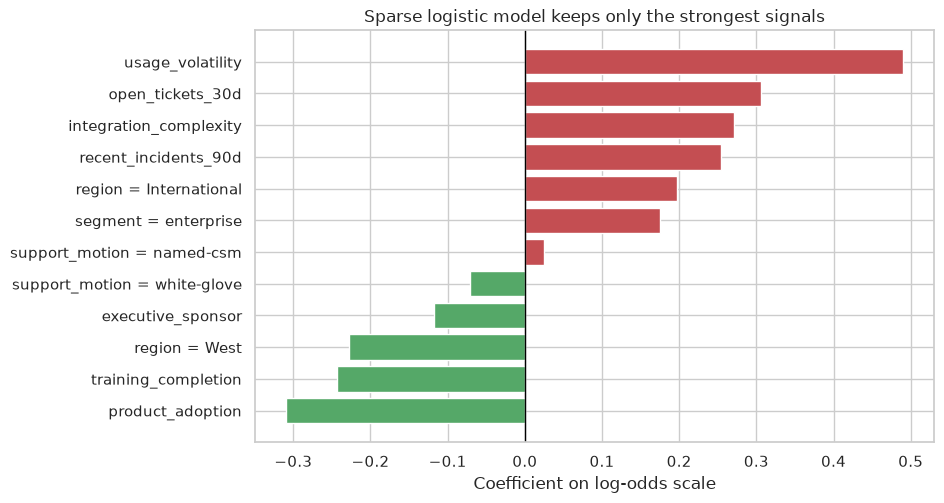

In [6]:
# Section focus: 5. Sparse Logistic Models as Deliberate Design Choices.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

sparse_logit_model = Pipeline(
    steps=[
        ('prep', transparent_prep),
        ('model', LogisticRegression(penalty='l1', solver='saga', C=0.35, max_iter=6000)),
    ]
)

sparse_logit_model.fit(X_train, y_cls_train)
sparse_logit_prob = sparse_logit_model.predict_proba(X_test)[:, 1]
sparse_coef = coefficient_table_from_pipeline(sparse_logit_model)
sparse_coef['odds_ratio'] = np.exp(sparse_coef['coefficient'])
nonzero_sparse = sparse_coef.loc[sparse_coef['coefficient'].abs() > 1e-8].copy()

sparse_comparison = pd.DataFrame(
    [
        {'model': 'Dense logistic baseline', 'active_coefficients': int((dense_coef['coefficient'].abs() > 1e-8).sum()), **review_metrics(y_cls_test, dense_logit_prob)},
        {'model': 'Sparse logistic baseline', 'active_coefficients': int((sparse_coef['coefficient'].abs() > 1e-8).sum()), **review_metrics(y_cls_test, sparse_logit_prob)},
    ]
)

smart_display(sparse_comparison)
smart_display(nonzero_sparse[['feature', 'coefficient', 'odds_ratio']].head(14))

plot_sparse = pd.concat([nonzero_sparse.nsmallest(6, 'coefficient'), nonzero_sparse.nlargest(6, 'coefficient')]).drop_duplicates('feature').sort_values('coefficient')

fig, ax = plt.subplots(figsize=(9.6, 5.2))
colors = np.where(plot_sparse['coefficient'] > 0, '#c44e52', '#55a868')
ax.barh(plot_sparse['feature'], plot_sparse['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Sparse logistic model keeps only the strongest signals')
ax.set_xlabel('Coefficient on log-odds scale')
plt.tight_layout()
plt.show()


A sparse transparent model gives a cleaner answer to an important governance question: *which variables are truly carrying the deployment logic?*

This run delivers a useful caution. Performance stays essentially unchanged, but the $\ell_1$ penalty removes only one active coefficient relative to the dense logistic model. In other words, asking for sparsity still requires checking whether the score became meaningfully simpler. The right habit is to check how much simplification was actually achieved rather than assuming the regularizer bought interpretability for free.

## 6. From Sparse Logistic Model to Scorecard-Style Workflow

A scorecard replaces raw continuous features with interpretable bins and then assigns additive points. In abstract form,

$$
\text{Score}(x) = \sum_{j=1}^p \sum_{k=1}^{K_j} w_{jk} \mathbf{1}\{x_j \in B_{jk}\},
$$

where the $B_{jk}$ are bins and the weights $w_{jk}$ are chosen to approximate a predictive signal. Scorecards are attractive because they are easy to audit, easy to compute, and easy to communicate. Their cost is discretization: smooth information is compressed into a small number of operational buckets.

Here we build a scorecard-style logistic model using coarse bins and then translate the fitted coefficients into approximate integer points.

,model,roc_auc,average_precision,brier_score,log_loss
0,Sparse logistic baseline,0.755,0.211,0.043,0.172
1,Scorecard-style logistic,0.713,0.125,0.045,0.182


,feature_group,level,coefficient,points
11,adoption_bin,0.70+,-1.191,-6
10,adoption_bin,0.45-0.70,-0.322,-2
4,complexity_bin,5-6,0.222,1
5,complexity_bin,7+,0.478,2
14,delay_bin,8+,0.287,1
16,incident_bin,1,0.193,1
17,incident_bin,2+,0.658,3
26,region,West,-0.212,-1
25,region,South,0.188,1
27,region,International,0.276,1


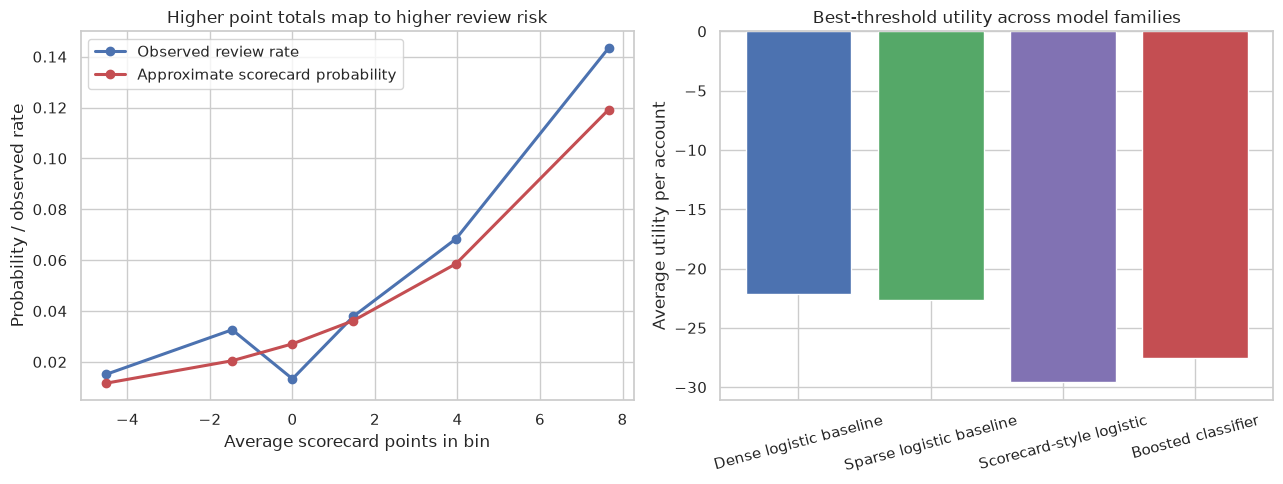

,model,threshold,mean_utility,review_share,precision,recall
0,Dense logistic baseline,0.080,-22.176,0.151,0.176,0.544
1,Sparse logistic baseline,0.060,-22.671,0.230,0.130,0.612
2,Scorecard-style logistic,0.070,-29.600,0.198,0.130,0.524
3,Boosted classifier,0.060,-27.552,0.211,0.129,0.553


In [7]:
# Section focus: 6. From Sparse Logistic Model to Scorecard-Style Workflow.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

scorecard_features = ['tickets_bin', 'complexity_bin', 'training_bin', 'adoption_bin', 'delay_bin', 'incident_bin', 'volatility_bin', 'segment', 'region']

score_X_train = make_scorecard_frame(X_train)
score_X_test = make_scorecard_frame(X_test)

scorecard_prep = ColumnTransformer(
    transformers=[
        ('cat', make_one_hot_encoder(categories=[SCORECARD_LEVELS[name] for name in scorecard_features], drop='first'), scorecard_features),
    ]
)

scorecard_model = Pipeline(
    steps=[
        ('prep', scorecard_prep),
        ('model', LogisticRegression(penalty='l1', solver='saga', C=0.55, max_iter=6000)),
    ]
)

scorecard_model.fit(score_X_train, y_cls_train)
scorecard_prob = scorecard_model.predict_proba(score_X_test)[:, 1]

scorecard_compare = pd.DataFrame(
    [
        {'model': 'Sparse logistic baseline', **review_metrics(y_cls_test, sparse_logit_prob)},
        {'model': 'Scorecard-style logistic', **review_metrics(y_cls_test, scorecard_prob)},
    ]
)

point_table = scorecard_points_table(scorecard_model, point_scale=0.20)
point_table_display = point_table.loc[point_table['points'] != 0].copy()
point_table_display = point_table_display.sort_values(['feature_group', 'points'])

smart_display(scorecard_compare)
smart_display(point_table_display)

scorecard_design = np.asarray(scorecard_model.named_steps['prep'].transform(score_X_test))
scorecard_coef = np.asarray(scorecard_model.named_steps['model'].coef_).ravel()
point_scale = 0.20
rounded_points = np.round(scorecard_coef / point_scale).astype(int)
point_totals = scorecard_design @ rounded_points
approx_prob = sigmoid(scorecard_model.named_steps['model'].intercept_[0] + point_scale * point_totals)

score_distribution = pd.DataFrame({'points': point_totals, 'probability': approx_prob, 'outcome': y_cls_test.to_numpy()})
score_bins = (
    score_distribution.groupby(pd.qcut(score_distribution['points'], q=6, duplicates='drop'), observed=False)
    .agg(mean_points=('points', 'mean'), mean_probability=('probability', 'mean'), observed_rate=('outcome', 'mean'))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
axes[0].plot(score_bins['mean_points'], score_bins['observed_rate'], marker='o', linewidth=2.2, color='#4c72b0', label='Observed review rate')
axes[0].plot(score_bins['mean_points'], score_bins['mean_probability'], marker='o', linewidth=2.2, color='#c44e52', label='Approximate scorecard probability')
axes[0].set_title('Higher point totals map to higher review risk')
axes[0].set_xlabel('Average scorecard points in bin')
axes[0].set_ylabel('Probability / observed rate')
axes[0].legend(frameon=True)

best_dense = policy_summary(dense_logit_prob, y_cls_test.to_numpy(), thresholds).loc[lambda d: d['mean_utility'].idxmax()]
best_sparse = policy_summary(sparse_logit_prob, y_cls_test.to_numpy(), thresholds).loc[lambda d: d['mean_utility'].idxmax()]
best_scorecard = policy_summary(scorecard_prob, y_cls_test.to_numpy(), thresholds).loc[lambda d: d['mean_utility'].idxmax()]
best_boost = policy_summary(boost_cls_prob, y_cls_test.to_numpy(), thresholds).loc[lambda d: d['mean_utility'].idxmax()]

utility_rank = pd.DataFrame(
    [
        {'model': 'Dense logistic baseline', **best_dense.to_dict()},
        {'model': 'Sparse logistic baseline', **best_sparse.to_dict()},
        {'model': 'Scorecard-style logistic', **best_scorecard.to_dict()},
        {'model': 'Boosted classifier', **best_boost.to_dict()},
    ]
)

axes[1].bar(utility_rank['model'], utility_rank['mean_utility'], color=['#4c72b0', '#55a868', '#8172b3', '#c44e52'])
axes[1].set_title('Best-threshold utility across model families')
axes[1].set_ylabel('Average utility per account')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

smart_display(utility_rank[['model', 'threshold', 'mean_utility', 'review_share', 'precision', 'recall']])


The scorecard-style model compresses the problem aggressively, but in this run it is not especially competitive. The binned score still tracks risk in the right direction, yet its predictive metrics and best-threshold utility are clearly worse than the dense and sparse logistic baselines.

That does not make scorecards unimportant. It means the present binning scheme throws away too much information for this task. A scorecard is still attractive when auditability, hand-checkable logic, and communication simplicity dominate. But this example also shows the real cost of discretization: transparency can remain high while decision quality drops materially.

## 7. When Is a Transparent Baseline Already Good Enough?

A practical rule is to compare the best transparent model against the best flexible model on three axes:

1. **Predictive loss**: how much accuracy is given up?
2. **Decision value**: how much deployment utility is given up?
3. **Governance burden**: how much explanation machinery, documentation effort, and review complexity are added?

One way to formalize the choice is

$$
\text{Choose transparent model if } \hat V(f_{\text{flex}}) - \hat V(f_{\text{trans}}) \leq \tau,
$$

where $\tau$ is the minimum utility gain required to justify added opacity. This is not a universal constant. It depends on domain risk, auditability requirements, reviewer capacity, and whether the organization can even act on a more complex explanation pipeline safely.

The important shift is conceptual: the transparent baseline is not a toy. It is a legitimate deployment option that the flexible model must outperform by enough to matter.

In this run, the flexible alternative does not clear that bar. The dense logistic baseline is stronger than the boosted classifier, and all candidate policies still have negative best-threshold utility. So the practical conclusion is not "deploy the black box." It is "revisit the action rule, payoff structure, or feature set before treating any model as deployment-ready."

## 8. Practical Takeaways

This notebook supports five takeaways.

1. Transparent models should be built early because they clarify both the data and the decision problem.
2. Linear and logistic baselines can outperform more flexible alternatives on structured operational data, as they do in this run.
3. Sparsity should be verified empirically rather than assumed; a weak $\ell_1$ penalty may barely simplify the deployed logic.
4. Scorecard-style models buy auditability, but coarse bins can impose a real predictive and utility cost.
5. If all candidate policies still have negative utility, the next step is to redesign the decision workflow rather than argue only about model complexity.

The next notebook moves from baseline models to the subtleties of interpreting coefficients, odds ratios, and response surfaces correctly.

## References

1. Rudin, C. (2019). *Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead*. Nature Machine Intelligence, 1(5), 206-215. [https://doi.org/10.1038/s42256-019-0048-x](https://doi.org/10.1038/s42256-019-0048-x)
2. Ustun, B., & Rudin, C. (2016). *Supersparse linear integer models for optimized medical scoring systems*. Machine Learning, 102(3), 349-391. [https://doi.org/10.1007/s10994-015-5528-6](https://doi.org/10.1007/s10994-015-5528-6)
3. Caruana, R., Lou, Y., Gehrke, J., Koch, P., Sturm, M., & Elhadad, N. (2015). *Intelligible Models for HealthCare*. Proceedings of the 21st ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 1721-1730. [https://doi.org/10.1145/2783258.2788613](https://doi.org/10.1145/2783258.2788613)
4. Murdoch, W. J., Singh, C., Kumbier, K., Abbasi-Asl, R., & Yu, B. (2019). *Definitions, methods, and applications in interpretable machine learning*. Proceedings of the National Academy of Sciences, 116(44), 22071-22080. [https://doi.org/10.1073/pnas.1900654116](https://doi.org/10.1073/pnas.1900654116)
5. Lipton, Z. C. (2018). *The mythos of model interpretability*. Communications of the ACM, 61(10), 36-43. [https://doi.org/10.1145/3233231](https://doi.org/10.1145/3233231)
6. Angelino, E., Larus-Stone, N., Alabi, D., Seltzer, M., & Rudin, C. (2017). *Learning Certifiably Optimal Rule Lists*. Proceedings of the 23rd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 35-44. [https://doi.org/10.1145/3097983.3098047](https://doi.org/10.1145/3097983.3098047)
